# Object Detection Using Laptop Camera
# Name:Sharveshwaran M
# Reg:212224240150

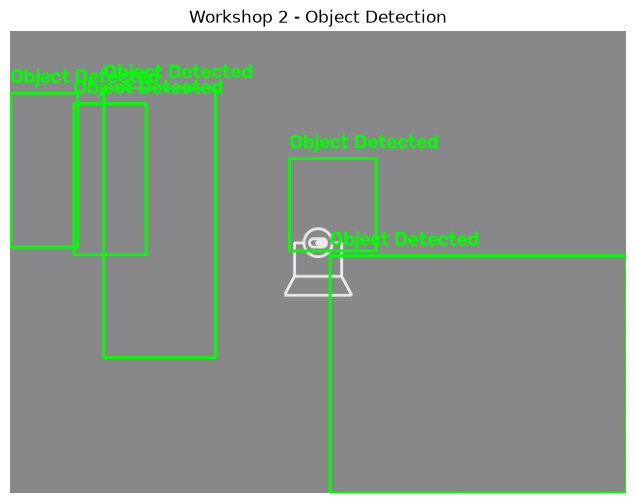

In [ ]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Open webcam using DirectShow
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("Error: Cannot open webcam")
else:
    print("Webcam started successfully.")

    # Background subtractor
    bg_subtractor = cv2.createBackgroundSubtractorMOG2(
        history=500,
        varThreshold=50,
        detectShadows=True
    )

    # Morphological kernel
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    try:
        while True:

            # Read frame
            ret, frame = cap.read()

            if not ret:
                print("Cannot read frame from webcam")
                break

            # Apply background subtraction
            mask = bg_subtractor.apply(frame)

            # Remove small noise
            mask = cv2.morphologyEx(
                mask,
                cv2.MORPH_OPEN,
                kernel
            )

            # Dilate foreground regions
            mask = cv2.morphologyEx(
                mask,
                cv2.MORPH_DILATE,
                kernel
            )

            # Find contours
            contours, _ = cv2.findContours(
                mask,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            # Detect objects
            for contour in contours:

                area = cv2.contourArea(contour)

                # Ignore small objects
                if area > 2500:

                    x, y, w, h = cv2.boundingRect(contour)

                    # Draw bounding box
                    cv2.rectangle(
                        frame,
                        (x, y),
                        (x + w, y + h),
                        (0, 255, 0),
                        2
                    )

                    # Display text
                    cv2.putText(
                        frame,
                        "Object Detected",
                        (x, max(y - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        (0, 255, 0),
                        2
                    )

            # Convert BGR → RGB
            frame_rgb = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            # Display in Jupyter
            clear_output(wait=True)

            plt.figure(figsize=(10, 6))
            plt.imshow(frame_rgb)
            plt.axis("off")
            plt.title("Workshop 2 - Object Detection")
            display(plt.gcf())
            plt.close()

    except KeyboardInterrupt:
        print("Stopping webcam...")

    finally:
        cap.release()
        print("Webcam released.")